# Ilbay-Yupa et al. 2022 Regions from CHIRPS 

In [ ]:
'''
Background
A part of our discussions in Dec 2025-Jan 2026, it turned out the need to crop the high reolution CHIRPS dataset using the shapefiles (.shp) that Mariana Luna-Cadena prepared during her BSc. Thesis (linkxxxx).
Here I provide the steps to obtain the 22 regions 
'''

In [1]:
import pyleoclim as pyleo

In [2]:
pyleo.utils.available_dataset_names()

['SOI',
 'NINO3',
 'HadCRUT5',
 'AIR',
 'LR04',
 'AACO2',
 'EDC-dD',
 'GISP2',
 'cenogrid_d18O',
 'cenogrid_d13C']

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [My BP]', ylabel='$\\delta^{18} \\mathrm{O}$ [‰ VPDB]'>)

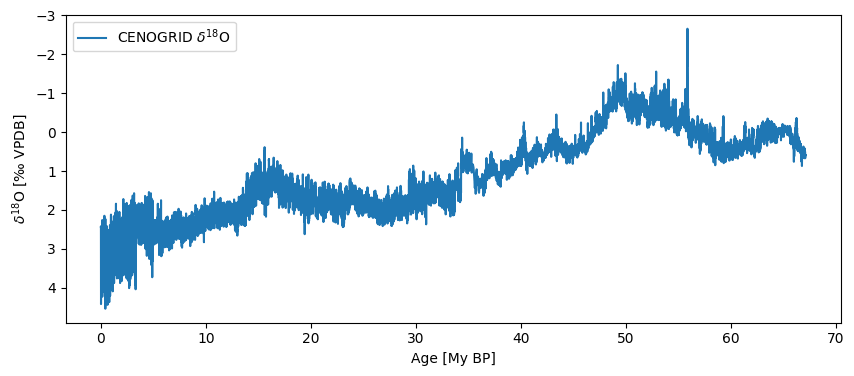

In [3]:
ts = pyleo.utils.load_dataset('cenogrid_d18O')
ts.plot(invert_yaxis=True)

In [1]:
import os
import subprocess

In [ ]:
# Directories
input_dir = "../data/regions_ilbaync"
output_dir = "..data/regions_ilbaytxt"

# Target grid file
target_grid_file = os.path.join(input_dir, "target_grid.txt")

# Mask file
mask_file = os.path.join(input_dir, "../data/RAIN4PE/RAIN4PE_daily_0.1d_1981_2015_v1.0.nc")

# List of raw NetCDF files (R1.nc to R23.nc)
nc_files = [f"R{i}.nc" for i in range(1, 24)]

# Loop over each file and apply the operations
for nc_file in nc_files:
    # Define file paths
    input_nc = os.path.join(input_dir, nc_file)
    reprojected_nc = os.path.join(input_dir, f"{nc_file.split('.')[0]}_reprojected.nc")
    remapped_nc = os.path.join(input_dir, f"{nc_file.split('.')[0]}_remapped.nc")
    masked_nc = os.path.join(input_dir, f"{nc_file.split('.')[0]}F.nc")
    mean_nc = os.path.join(input_dir, f"{nc_file.split('.')[0]}_1981_2015.nc")
    output_txt = os.path.join(output_dir, f"{nc_file.split('.')[0]}_1981_2015.txt")
    
    # Step 1: Reproject Mercator to Lat-Long
    cmd1 = f"gdalwarp -t_srs EPSG:4326 -overwrite {input_nc} {reprojected_nc}"
    print(f"Running: {cmd1}")
    subprocess.run(cmd1, shell=True, check=True)
    
    # Step 2: Remap using target_grid.txt
    cmd2 = f"cdo remapbil,{target_grid_file} {reprojected_nc} {remapped_nc}"
    print(f"Running: {cmd2}")
    subprocess.run(cmd2, shell=True, check=True)
    
    # Step 3: Mask
    cmd3 = f"cdo ifthen {remapped_nc} {mask_file} {masked_nc}"
    print(f"Running: {cmd3}")
    subprocess.run(cmd3, shell=True, check=True)
    
    # Step 4: Obtain the mean and save as R1_1981_2015.nc
    cmd4 = f"cdo -fldmean {masked_nc} {mean_nc}"
    print(f"Running: {cmd4}")
    subprocess.run(cmd4, shell=True, check=True)
    
    # Step 5: Output as .txt
    cmd5 = f"cdo outputtab,date,lon,lat,value {mean_nc} > {output_txt}"
    print(f"Running: {cmd5}")
    subprocess.run(cmd5, shell=True, check=True)
    
print("Processing completed for all files!")


## Test creating time series